In [22]:
import sys
import re
from pathlib import Path

CODE_DIR = (Path.cwd().parent).resolve()
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

from cloudprompts.evaluation import evaluate_segmentation

In [ ]:
LEVEL_ROOT = Path("../inference/clipseg_cloudsen12plus_prompt_ladder").expanduser().resolve()

LEVEL_GLOB = "**/L[1-4]"


GT_DIR = Path("../data/cloudsen12plus/export_p509_high_npz/test/masks").expanduser().resolve()

OUT_DIR = (Path.cwd().resolve() / "ladder_eval").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL = "clipseg"
DATASET = "cloudsen12plus"
NUM_CLASSES = 4
CLASS_NAMES = ["clear", "thick_cloud", "thin_cloud", "cloud_shadow"]

GT_KEY = "mask"
PRED_KEY = "mask"
GT_EXT = ".npz"
PRED_EXT = ".npz"

IGNORE_INDEX = None
STRICT = True

print("LEVEL_ROOT:", LEVEL_ROOT, "exists:", LEVEL_ROOT.exists())
print("GT_DIR    :", GT_DIR, "exists:", GT_DIR.exists())
print("OUT_DIR   :", OUT_DIR, "exists:", OUT_DIR.exists())

LEVEL_ROOT: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder exists: True
GT_DIR    : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/data/cloudsen12plus/export_p509_high_npz/test/masks exists: True
OUT_DIR   : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval exists: True


In [ ]:
def discover_level_dirs():
    if "LEVEL_DIRS" in globals():
        dirs = [Path(p).expanduser().resolve() for p in LEVEL_DIRS]
    else:
        dirs = [p.resolve() for p in LEVEL_ROOT.glob(LEVEL_GLOB) if p.is_dir()]

    def level_num(p: Path) -> int:
        m = re.search(r"\bl([1-4])\b", p.name)
        if not m:
            m = re.search(r"[\\/](l[1-4])[\\/]", str(p))
        if not m:
            return 999
        return int(m.group(1)[1])

    dirs = sorted(dirs, key=level_num)
    return dirs

LEVEL_DIRS_FOUND = discover_level_dirs()
print("Found level dirs:")
for d in LEVEL_DIRS_FOUND:
    print(" -", d)


Found level dirs:
 - /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L3
 - /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L4
 - /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L2
 - /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L1


In [ ]:
def sanitize_stage(s: str) -> str:
    s = s.strip()
    s = re.sub(r"[^A-Za-z0-9_\-]+", "_", s)
    return s

def extract_level_tag(level_dir: Path) -> str:
    m = re.search(r"\b(l[1-4])\b", level_dir.name)
    if m:
        return m.group(1)
    m = re.search(r"[\\/](l[1-4])[\\/]", str(level_dir))
    if m:
        return m.group(1)
    return level_dir.name

def pick_latest_checkpoint(level_dir: Path) -> Path | None:
    ckpts = list(level_dir.glob("checkpoint-*"))
    if not ckpts:
        return None
    def step(p: Path) -> int:
        m = re.search(r"checkpoint-(\d+)", p.name)
        return int(m.group(1)) if m else -1
    ckpts.sort(key=step)
    return ckpts[-1]

def resolve_pred_dir(level_dir: Path) -> Path:
    if (level_dir / "masks").is_dir():
        return level_dir / "masks"

    ckpt = pick_latest_checkpoint(level_dir)
    if ckpt and (ckpt / "masks").is_dir():
        return ckpt / "masks"

    if list(level_dir.glob(f"*{PRED_EXT}")):
        return level_dir
    
    candidates = [p for p in level_dir.rglob("masks") if p.is_dir()]
    if candidates:
        
        candidates.sort(key=lambda p: len(list(p.glob(f"*{PRED_EXT}"))))
        return candidates[-1]

    raise FileNotFoundError(f"Could not find prediction masks under: {level_dir}")

def safe_rename(src: Path, dst: Path) -> None:
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists():
        dst.unlink()
    src.rename(dst)


In [ ]:
results = []

for level_dir in LEVEL_DIRS_FOUND:
    tag = extract_level_tag(level_dir)
    stage = sanitize_stage(tag)
    pred_dir = resolve_pred_dir(level_dir)

    print(f"\n[INFO] Level: {tag}")
    print("  level_dir:", level_dir)
    print("  pred_dir :", pred_dir)
    print("  out_dir  :", OUT_DIR)
    print("  stage    :", stage)

    out = evaluate_segmentation(
        gt_dir=GT_DIR,
        pred_dir=pred_dir,
        model=MODEL,
        dataset=DATASET,
        stage=stage,
        num_classes=NUM_CLASSES,
        class_names=CLASS_NAMES,
        run_root=OUT_DIR,
        gt_key=GT_KEY,
        pred_key=PRED_KEY,
        gt_ext=GT_EXT,
        pred_ext=PRED_EXT,
        ignore_index=IGNORE_INDEX,
        strict=STRICT,
    )

    cm_src = Path(out["cm_csv"])
    miou_src = Path(out["miou_csv"])

    cm_dst = OUT_DIR / f"{tag}_cm.csv"
    iou_dst = OUT_DIR / f"{tag}_iou.csv"

    safe_rename(cm_src, cm_dst)
    safe_rename(miou_src, iou_dst)

    print("  ->", cm_dst)
    print("  ->", iou_dst)

    results.append({
        "level": tag,
        "level_dir": str(level_dir),
        "pred_dir": str(pred_dir),
        "cm_csv": str(cm_dst),
        "iou_csv": str(iou_dst),
        "aggregate_miou": out.get("aggregate_miou"),
        "aggregate_pixel_acc": out.get("aggregate_pixel_acc"),
    })

results



[INFO] Level: L3
  level_dir: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L3
  pred_dir : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L3/masks
  out_dir  : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval
  stage    : L3


/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/cloudprompts/evaluation.py:218: RuntimeWarning: invalid value encountered in divide
  per_class_iou = np.where(denom > 0, tp / denom, np.nan)


  -> /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval/L3_cm.csv
  -> /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval/L3_iou.csv

[INFO] Level: L4
  level_dir: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L4
  pred_dir : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L4/masks
  out_dir  : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval
  stage    : L4


/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/cloudprompts/evaluation.py:218: RuntimeWarning: invalid value encountered in divide
  per_class_iou = np.where(denom > 0, tp / denom, np.nan)


  -> /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval/L4_cm.csv
  -> /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval/L4_iou.csv

[INFO] Level: L2
  level_dir: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L2
  pred_dir : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L2/masks
  out_dir  : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval
  stage    : L2


/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/cloudprompts/evaluation.py:218: RuntimeWarning: invalid value encountered in divide
  per_class_iou = np.where(denom > 0, tp / denom, np.nan)


  -> /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval/L2_cm.csv
  -> /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval/L2_iou.csv

[INFO] Level: L1
  level_dir: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L1
  pred_dir : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L1/masks
  out_dir  : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval
  stage    : L1


/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/cloudprompts/evaluation.py:218: RuntimeWarning: invalid value encountered in divide
  per_class_iou = np.where(denom > 0, tp / denom, np.nan)


  -> /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval/L1_cm.csv
  -> /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval/L1_iou.csv


[{'level': 'L3',
  'level_dir': '/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L3',
  'pred_dir': '/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L3/masks',
  'cm_csv': '/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval/L3_cm.csv',
  'iou_csv': '/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval/L3_iou.csv',
  'aggregate_miou': 0.22330353736318823,
  'aggregate_pixel_acc': 0.44860140678210136},
 {'level': 'L4',
  'level_dir': '/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming H

In [28]:
import pandas as pd

for r in results:
    p = Path(r["iou_csv"])
    df = pd.read_csv(p)
    agg = df[df["id"] == "__aggregate__"]
    print("\n", r["level"], "aggregate:")
    display(agg)



 L3 aggregate:


,id,miou,pixel_acc,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow
975,__aggregate__,0.223304,0.448601,0.47936,0.315328,0.042541,0.055986



 L4 aggregate:


,id,miou,pixel_acc,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow
975,__aggregate__,0.20133,0.471233,0.501102,0.220324,0.030404,0.053489



 L2 aggregate:


,id,miou,pixel_acc,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow
975,__aggregate__,0.124869,0.290356,0.151543,0.276316,0.012656,0.058961



 L1 aggregate:


,id,miou,pixel_acc,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow
975,__aggregate__,0.204965,0.491326,0.399795,0.377907,0.013533,0.028624


In [ ]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
LOW_DATA_CSV = Path("../inference/clipseg_cloudsen12plus_fft_low_data/low_data_ladder.csv")

FFT_MIOU_CSV = Path("../inference/clipseg_cloudsen12plus_fft/miou_clipseg_cloudsen12plus_fft_eval.csv")

PROMPT_EVAL_DIR = Path("./ladder_eval")

print("LOW_DATA_CSV:", LOW_DATA_CSV, "exists:", LOW_DATA_CSV.exists())
print("FFT_MIOU_CSV:", FFT_MIOU_CSV, "exists:", FFT_MIOU_CSV.exists())
print("PROMPT_EVAL_DIR:", PROMPT_EVAL_DIR, "exists:", PROMPT_EVAL_DIR.exists())


LOW_DATA_CSV: ../inference/clipseg_cloudsen12plus_fft_low_data/low_data_ladder.csv exists: True
FFT_MIOU_CSV: ../inference/clipseg_cloudsen12plus_fft/miou_clipseg_cloudsen12plus_fft_eval.csv exists: True
PROMPT_EVAL_DIR: ladder_eval exists: True


In [ ]:
def get_agg_row(df: pd.DataFrame, csv_path: Path) -> pd.Series:
    if "id" not in df.columns:
        raise ValueError(f"'id' column missing in {csv_path}")
    agg = df[df["id"] == "__aggregate__"]
    if agg.empty:
        raise ValueError(f"No __aggregate__ row found in {csv_path}")
    return agg.iloc[0]

low_df = pd.read_csv(LOW_DATA_CSV)
low_df["pct"] = low_df["pct"].astype(int)
low_df = low_df[(low_df["pct"] >= 10) & (low_df["pct"] <= 90)].sort_values("pct")

fft_df = pd.read_csv(FFT_MIOU_CSV)
fft_agg = get_agg_row(fft_df, FFT_MIOU_CSV)

print("low_df columns:", list(low_df.columns)[:12], "...")
print("FFT aggregate miou:", float(fft_agg["miou"]))


low_df columns: ['pct', 'n_seeds', 'miou_mean', 'pixel_acc_mean', 'iou_clear_mean', 'iou_thick_cloud_mean', 'iou_thin_cloud_mean', 'iou_cloud_shadow_mean', 'miou_std', 'pixel_acc_std', 'iou_clear_std', 'iou_thick_cloud_std'] ...
FFT aggregate miou: 0.6572447410809639


In [ ]:
def extract_level_num(name: str) -> int:
    m = re.match(r"l(\d+)$", name)
    return int(m.group(1)) if m else 999

levels = ["l1", "l2", "l3", "l4"]
prompt_rows = []

for lvl in levels:
    p = PROMPT_EVAL_DIR / f"{lvl}_iou.csv"
    if not p.exists():
        print(f"[WARN] Missing {p} (skipping {lvl})")
        continue

    df = pd.read_csv(p)
    agg = get_agg_row(df, p)

    prompt_rows.append({
        "label": lvl.upper(),
        "level": lvl,
        "miou": float(agg["miou"]),
        "iou_clear": float(agg["iou_clear"]),
        "iou_thick_cloud": float(agg["iou_thick_cloud"]),
        "iou_thin_cloud": float(agg["iou_thin_cloud"]),
        "iou_cloud_shadow": float(agg["iou_cloud_shadow"]),
    })

prompt_df = pd.DataFrame(prompt_rows).sort_values(by="level", key=lambda s: s.map(extract_level_num))
display(prompt_df)


,label,level,miou,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow
0,L1,l1,0.204965,0.399795,0.377907,0.013533,0.028624
1,L2,l2,0.124869,0.151543,0.276316,0.012656,0.058961
2,L3,l3,0.223304,0.479360,0.315328,0.042541,0.055986
3,L4,l4,0.201330,0.501102,0.220324,0.030404,0.053489


In [36]:
ZS_MIOU_CSV = Path("../inference/clipseg_cloudsen12plus_zs/miou_clipseg_cloudsen12plus_zs_eval.csv")
print("ZS_MIOU_CSV:", ZS_MIOU_CSV, "exists:", ZS_MIOU_CSV.exists())

zs_df = pd.read_csv(ZS_MIOU_CSV)
zs_agg = get_agg_row(zs_df, ZS_MIOU_CSV)

print("ZS aggregate miou:", float(zs_agg["miou"]))

ZS_MIOU_CSV: ../inference/clipseg_cloudsen12plus_zs/miou_clipseg_cloudsen12plus_zs_eval.csv exists: True
ZS aggregate miou: 0.2550400406013244


In [ ]:
pct_labels = [f"{p}%" for p in low_df["pct"].tolist()]
x_labels = ["ZS"] + prompt_df["label"].tolist() + pct_labels + ["FFT"]

x_pos = {lab: i for i, lab in enumerate(x_labels)}

ft_x = [x_pos[f"{p}%"] for p in low_df["pct"].tolist()] + [x_pos["FFT"]]

pl_x = [x_pos[lab] for lab in prompt_df["label"].tolist()]

zs_x = x_pos["ZS"]

print("x_labels:", x_labels)
print("zs_x:", zs_x)
print("pl_x:", pl_x)
print("ft_x:", ft_x)


x_labels: ['ZS', 'L1', 'L2', 'L3', 'L4', '10%', '20%', '30%', '40%', '50%', '60%', '70%', '80%', '90%', 'FFT']
zs_x: 0
pl_x: [1, 2, 3, 4]
ft_x: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


In [ ]:
def plot_overlay_with_zs(metric_base: str, title: str, ylabel: str):
    """
    metric_base:
      - "miou"
      - "iou_clear"
      - "iou_thick_cloud"
      - "iou_thin_cloud"
      - "iou_cloud_shadow"
    """
    if metric_base == "miou":
        ft_mean_col = "miou_mean"
        ft_std_col = "miou_std"
        zs_value = float(zs_agg["miou"])
        fft_value = float(fft_agg["miou"])
    else:
        ft_mean_col = f"{metric_base}_mean"
        ft_std_col = f"{metric_base}_std"
        zs_value = float(zs_agg[metric_base])
        fft_value = float(fft_agg[metric_base])


    ft_y = low_df[ft_mean_col].astype(float).tolist() + [fft_value]
    ft_yerr = low_df[ft_std_col].astype(float).tolist() + [0.0]


    pl_y = prompt_df[metric_base].astype(float).tolist()

    plt.figure(figsize=(11.5, 4.8))


    plt.plot([zs_x], [zs_value], marker="o", linestyle="none", label="Zero-shot (ZS)")


    plt.plot(pl_x, pl_y, marker="o", linestyle="-", label="Prompt ladder (L1–L4)")

    plt.step(ft_x, ft_y, where="mid", label="Fine-tune (mean across seeds)")
    plt.plot(ft_x, ft_y, marker="o")
    plt.errorbar(ft_x, ft_y, yerr=ft_yerr, fmt="none", capsize=3, alpha=0.9)

    plt.xticks(range(len(x_labels)), x_labels)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


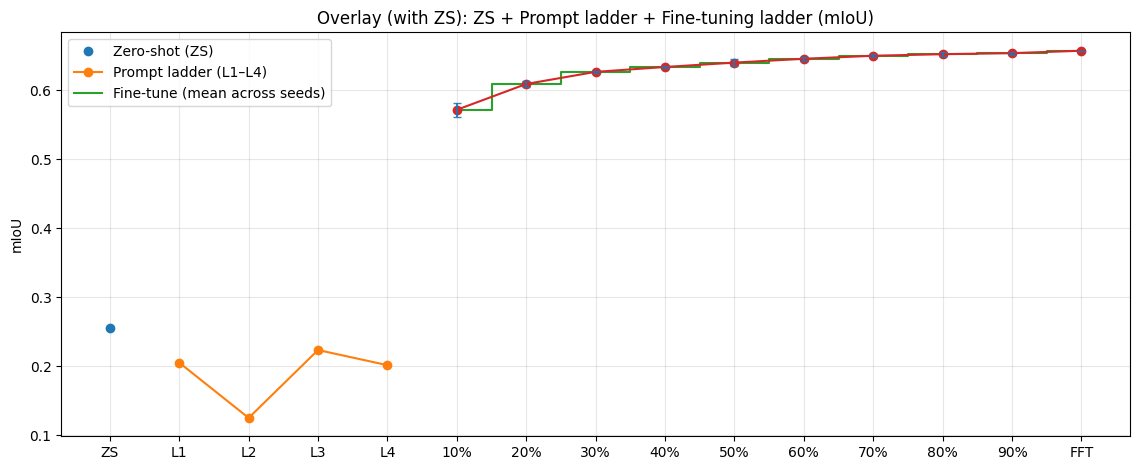

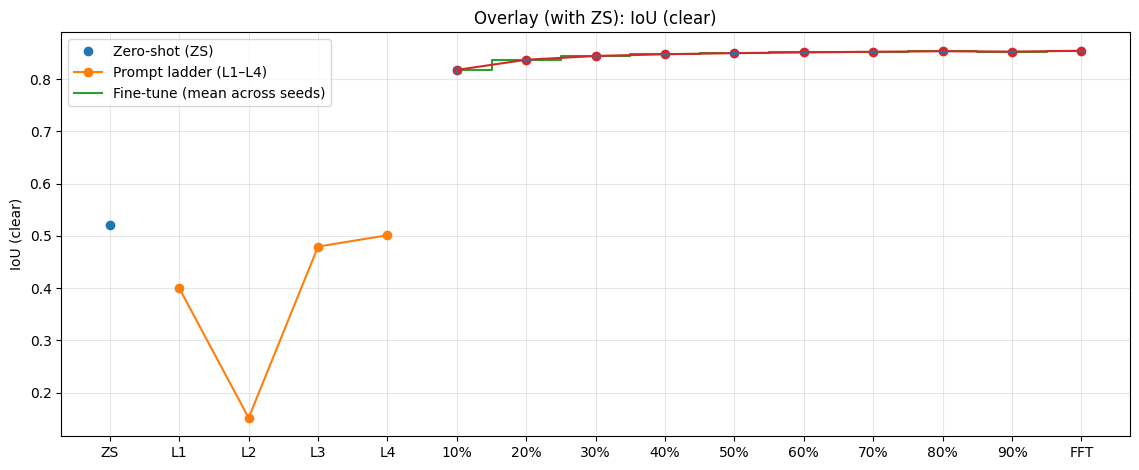

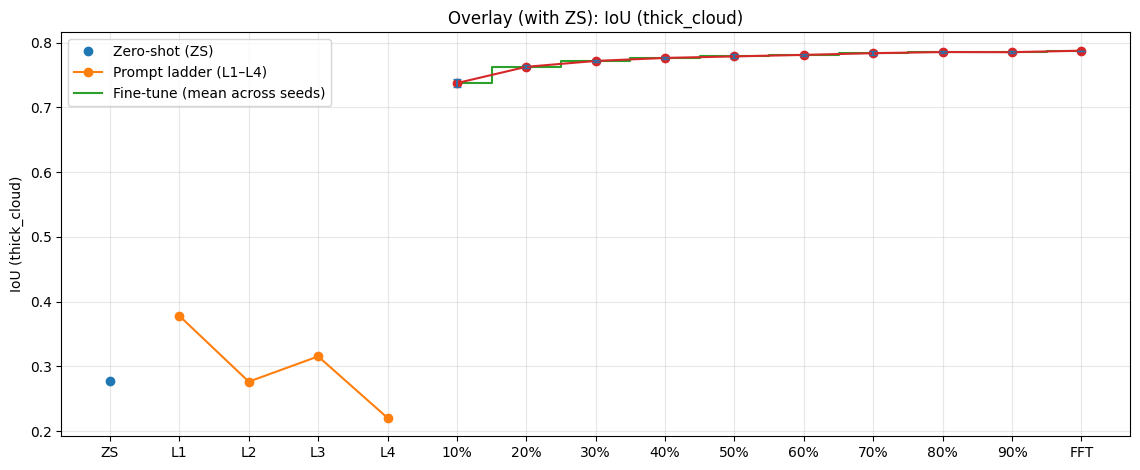

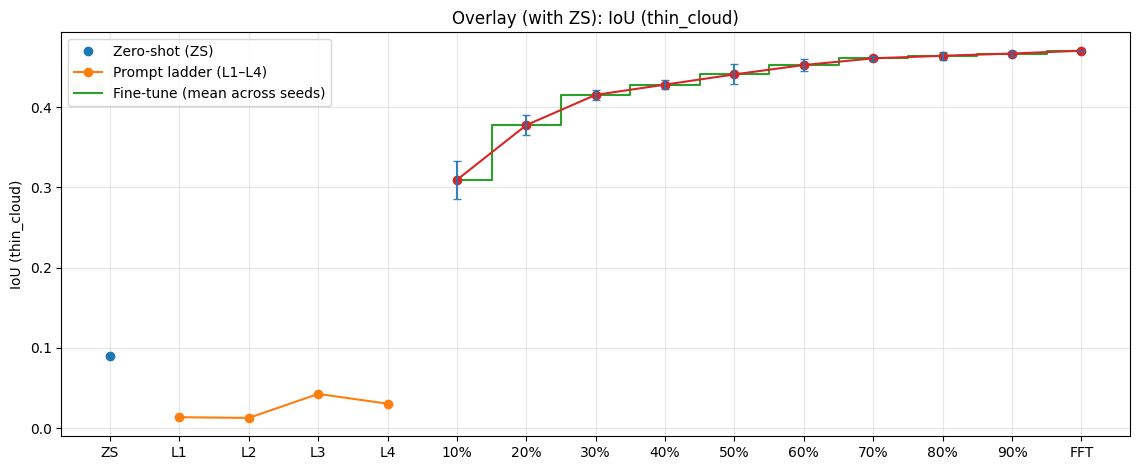

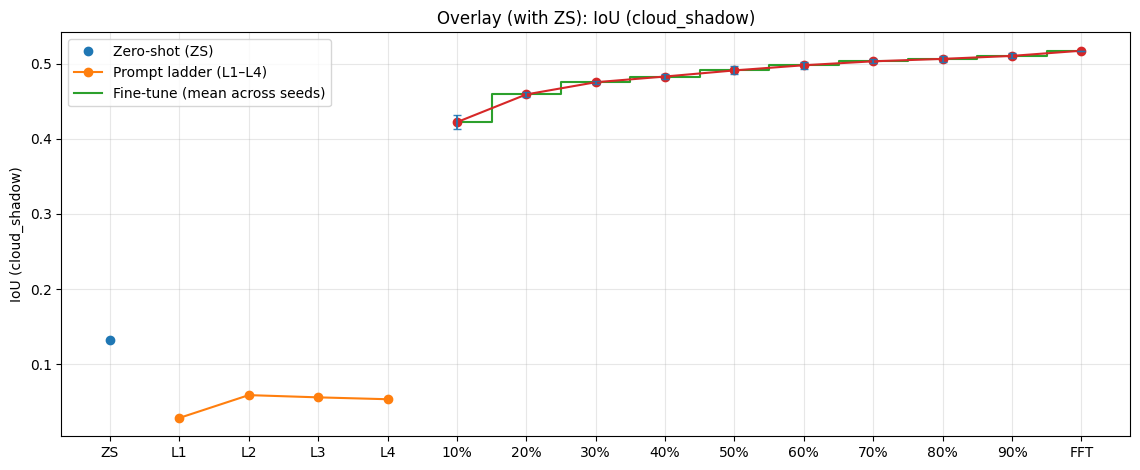

In [39]:
plot_overlay_with_zs("miou", "Overlay (with ZS): ZS + Prompt ladder + Fine-tuning ladder (mIoU)", "mIoU")

plot_overlay_with_zs("iou_clear", "Overlay (with ZS): IoU (clear)", "IoU (clear)")
plot_overlay_with_zs("iou_thick_cloud", "Overlay (with ZS): IoU (thick_cloud)", "IoU (thick_cloud)")
plot_overlay_with_zs("iou_thin_cloud", "Overlay (with ZS): IoU (thin_cloud)", "IoU (thin_cloud)")
plot_overlay_with_zs("iou_cloud_shadow", "Overlay (with ZS): IoU (cloud_shadow)", "IoU (cloud_shadow)")


- Label — bare class name (Zero Shot)
- Domain — EO/remote sensing grounding
- Exclusion — negative confuser suppression
- Appearance — visual descriptor
- Context — spatial and relational cues

L1_PROMPTS=(
  "a sentinel-2 satellite image showing clear sky"
  "a Sentinel-2 satellite image showing thick cloud coverage over the surface"
  "a Sentinel-2 satellite image showing thin cloud over the surface"
  "a Sentinel-2 satellite image showing cloud shadow cast on the surface"
)

L2_PROMPTS=(
  "a Sentinel-2 satellite image showing clear surface, not cloud, not thin cloud, not haze, not shadow"
  "a Sentinel-2 satellite image showing thick cloud, not thin cloud, not haze, not bright snow or ice, not desert surface"
  "a Sentinel-2 satellite image showing thin cloud, not thick cloud, not clear surface, not haze, not bright snow or ice"
  "a Sentinel-2 satellite image showing cloud shadow on the surface, not dark water, not dark vegetation, not urban shadow, not cloud"
)

L3_PROMPTS=(
  "a Sentinel-2 satellite image showing clear surface with natural land or ocean texture and consistent illumination, not cloud, not thin cloud, not haze, not shadow"
  "a Sentinel-2 satellite image showing thick cloud with bright white opaque mass and sharp well-defined edges, not thin cloud, not haze, not bright snow or ice, not desert surface"
  "a Sentinel-2 satellite image showing thin cloud with translucent semi-transparent veil allowing partial surface visibility beneath, not thick cloud, not clear surface, not haze, not bright snow or ice"
  "a Sentinel-2 satellite image showing cloud shadow as a dark low-reflectance region with soft diffuse edges uniformly dimming the surface below, not dark water, not dark vegetation, not urban shadow, not cloud"
)

L4_PROMPTS=(
  "a Sentinel-2 satellite image showing clear surface with natural land or ocean texture and consistent illumination, spatially coherent with surrounding terrain and distinct from cloud edges, not cloud, not thin cloud, not haze, not shadow"
  "a Sentinel-2 satellite image showing thick cloud with bright white opaque mass and sharp well-defined edges, casting shadow on surface below, spatially distinct from surrounding clear terrain, not thin cloud, not haze, not bright snow or ice, not desert surface"
  "a Sentinel-2 satellite image showing thin cloud with translucent semi-transparent veil allowing partial surface visibility beneath, appearing at cloud edges or as cirrus streaks, spatially transitional between thick cloud and clear regions, not thick cloud, not clear surface, not haze, not bright snow or ice"
  "a Sentinel-2 satellite image showing cloud shadow as a dark low-reflectance region with soft diffuse edges uniformly dimming the surface below, spatially offset from and geometrically correlated with nearby thick cloud, not dark water, not dark vegetation, not urban shadow, not cloud"
)